In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve

# === CONFIG ===
CSV_PATH = "output/5_dec_data_z8/puncta_summary.csv"  # path to mean_intensity_and_puncta output
INTENSITY_COL = 'cyto_mean_raw'
PUNCTA_COL = "has_puncta"

# Filtering / QC
MAX_SAT_FRAC = 1
# 0.02      # allow at most 2% saturated pixels per cell
MIN_CYTO_PIXELS = 0 
# 50     # discard tiny cells
MIN_INTENSITY = None    # e.g. 0 or None
MAX_INTENSITY = None  # e.g. 50000 or None

# Binning for step curve
N_BINS = 20              # number of bins for empirical step curve

# Bootstrapping
BOOTSTRAP_ITERS = 1000
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

INTENSITY_LABEL = "cyto_mean_raw"

In [30]:
df = pd.read_csv(CSV_PATH)
print("Columns:", df.columns.tolist())
print("Total cells:", len(df))

# Quick preview
df.head()

df['global_intensity_bg_sub'] = df.cyto_mean_raw - df.background_value_global


Columns: ['image_location', 'cyto_file', 'puncta_file', 'intensity_file', 'intensity_channel', 'cell_label', 'centroid_y', 'centroid_x', 'num_cyto_pixels', 'num_puncta_pixels', 'has_puncta', 'puncta_area_in_cell', 'puncta_density', 'background_method', 'background_value_global', 'norm_percentile', 'norm_value_pXX', 'local_bg_raw', 'local_bg_used', 'local_bg_source', 'local_bg_pixels_used', 'cyto_mean_raw', 'cyto_mean_bgsub', 'cyto_mean_norm', 'cyto_mean_bgsub_local', 'cyto_mean_norm_local', 'cyto_mean_bgsub_hybrid', 'sat_frac_cell', 'conc_estimate_hybrid', 'intensity_for_cs']
Total cells: 1184


In [31]:
print(f"Cells before filtering: {len(df)}")

# Check class balance
print("Puncta label counts (0/1):")
print(df[PUNCTA_COL].value_counts())

Cells before filtering: 1184
Puncta label counts (0/1):
has_puncta
1    782
0    402
Name: count, dtype: int64


In [19]:
df

,image_location,cyto_file,puncta_file,intensity_file,intensity_channel,cell_label,centroid_y,centroid_x,num_cyto_pixels,num_puncta_pixels,...,cyto_mean_raw,cyto_mean_bgsub,cyto_mean_norm,cyto_mean_bgsub_local,cyto_mean_norm_local,cyto_mean_bgsub_hybrid,sat_frac_cell,conc_estimate_hybrid,intensity_for_cs,global_intensity_bg_sub
0,0_Z008,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2,1,158.744268,1932.820597,22809,0,...,245.917618,75.917618,0.092133,71.917618,0.087279,71.917618,0.0,NaN,71.917618,75.917618
1,0_Z008,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2,2,311.401878,181.000744,24179,3321,...,1680.089355,1510.089233,1.832633,1286.089233,1.560788,1286.089233,0.0,NaN,1286.089233,1510.089355
2,0_Z008,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2,3,456.284678,1355.130992,21238,0,...,694.692261,524.692261,0.636762,307.692261,0.373413,307.692261,0.0,NaN,307.692261,524.692261
3,0_Z008,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2,4,488.067680,659.580437,47385,203,...,253.758957,83.758957,0.101649,43.758953,0.053106,43.758953,0.0,NaN,43.758953,83.758957
4,0_Z008,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2,5,670.695813,231.872655,28992,0,...,224.680008,54.680016,0.066359,60.680016,0.073641,60.680016,0.0,NaN,60.680016,54.680008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1169,9_Z008,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2,3,612.432711,2016.572473,39932,442,...,341.630737,185.630753,0.042851,185.630753,0.042851,185.630753,0.0,NaN,185.630753,185.630737
1170,9_Z008,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2,4,1249.667111,720.601784,32284,0,...,264.021454,108.021469,0.024936,100.021469,0.023089,100.021469,0.0,NaN,100.021469,108.021454
1171,9_Z008,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2,5,1450.615917,1252.903851,31212,0,...,288.663483,132.663498,0.030624,113.663498,0.026238,113.663498,0.0,NaN,113.663498,132.663483
1172,9_Z008,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2,6,1992.941285,1213.593388,23231,0,...,5420.869141,5264.869141,1.215344,4272.869141,0.986350,5264.869141,0.0,NaN,5264.869141,5264.869141


In [20]:
mask = np.ones(len(df), dtype=bool)

# Saturation filter
if "sat_frac_cell" in df.columns and MAX_SAT_FRAC is not None:
    mask &= df["sat_frac_cell"] <= MAX_SAT_FRAC

# Cell size filter
if "num_cyto_pixels" in df.columns and MIN_CYTO_PIXELS is not None:
    mask &= df["num_cyto_pixels"] >= MIN_CYTO_PIXELS

# Intensity range filters
if MIN_INTENSITY is not None:
    mask &= df[INTENSITY_COL] >= MIN_INTENSITY
if MAX_INTENSITY is not None:
    mask &= df[INTENSITY_COL] <= MAX_INTENSITY

df_filt = df[mask].copy()
print(f"Cells kept after filtering: {len(df_filt)}")

# Check class balance
print("Puncta label counts (0/1):")
print(df_filt[PUNCTA_COL].value_counts())


Cells kept after filtering: 1174
Puncta label counts (0/1):
has_puncta
1    626
0    548
Name: count, dtype: int64


In [21]:
df['cyto_mean_bgsub_hybrid'].describe()

count     1174.000000
mean       744.483111
std       1426.923992
min          3.910548
25%         80.665720
50%        233.921730
75%        701.219162
max      13881.473633
Name: cyto_mean_bgsub_hybrid, dtype: float64

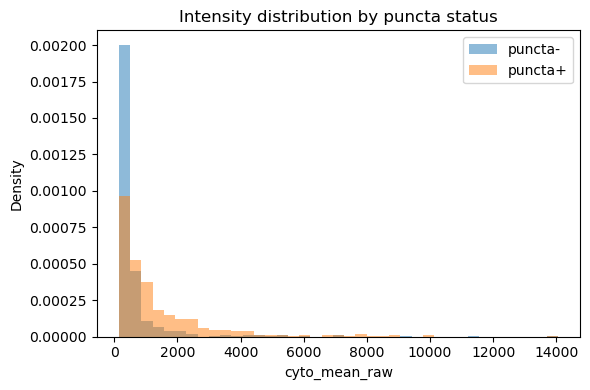

In [22]:
plt.figure(figsize=(6,4))

is_puncta = df_filt[PUNCTA_COL] == 1
int_pos = df_filt.loc[is_puncta, INTENSITY_COL].to_numpy()
int_neg = df_filt.loc[~is_puncta, INTENSITY_COL].to_numpy()

bins = np.linspace(df_filt[INTENSITY_COL].min(), df_filt[INTENSITY_COL].max(), 40)

plt.hist(int_neg, bins=bins, alpha=0.5, label="puncta-", density=True)
plt.hist(int_pos, bins=bins, alpha=0.5, label="puncta+", density=True)

plt.xlabel(
INTENSITY_LABEL)
plt.ylabel("Density")
plt.title("Intensity distribution by puncta status")
plt.legend()
plt.tight_layout()
plt.show()


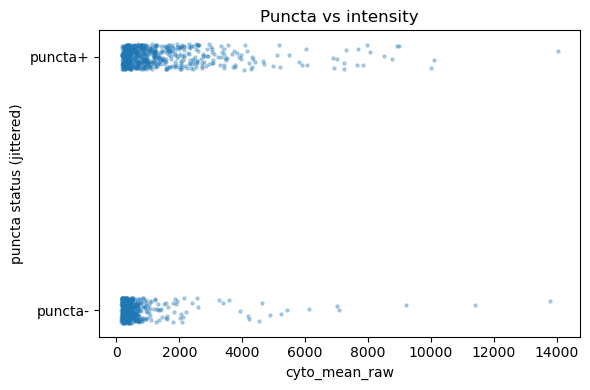

In [23]:
plt.figure(figsize=(6,4))

x = df_filt[INTENSITY_COL].to_numpy()
y = df_filt[PUNCTA_COL].to_numpy()

# jitter around 0 or 1 for visualization
np.random.seed(RANDOM_STATE)
y_jitter = y + (np.random.rand(len(y)) - 0.5) * 0.1

plt.scatter(x, y_jitter, s=5, alpha=0.3)
plt.yticks([0, 1], ["puncta-", "puncta+"])
plt.xlabel(INTENSITY_LABEL)
plt.ylabel("puncta status (jittered)")
plt.title("Puncta vs intensity")
plt.tight_layout()
plt.show()


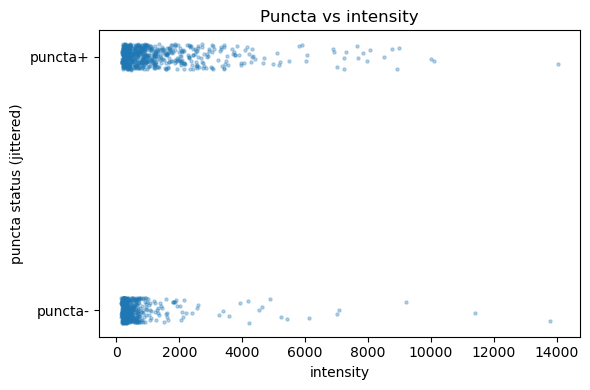

In [24]:
plt.figure(figsize=(6,4))

x = df_filt[INTENSITY_COL].to_numpy()
y = df_filt[PUNCTA_COL].to_numpy()

# jitter around 0 or 1 for visualization
y_jitter = y + (np.random.rand(len(y)) - 0.5) * 0.1

plt.scatter(x, y_jitter, s=5, alpha=0.3)
plt.yticks([0, 1], ["puncta-", "puncta+"])
plt.xlabel('intensity')
plt.ylabel("puncta status (jittered)")
plt.title("Puncta vs intensity")
plt.tight_layout()
plt.show()

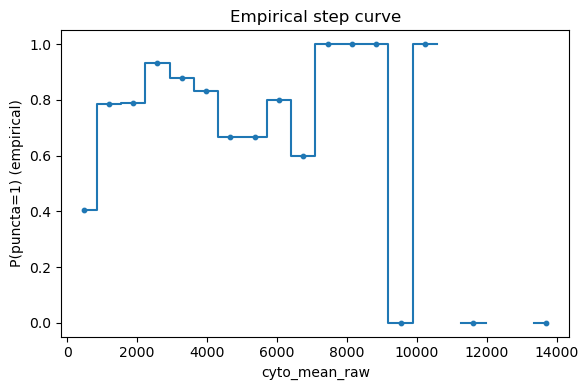

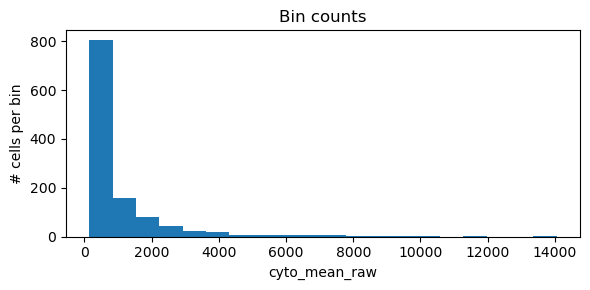

In [25]:
# Define bins
bin_edges = np.linspace(df_filt[INTENSITY_COL].min(),
                        df_filt[INTENSITY_COL].max(),
                        N_BINS + 1)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_p = []  # fraction puncta+ in each bin
bin_n = []  # total cells per bin

intensity = df_filt[INTENSITY_COL].to_numpy()
labels = df_filt[PUNCTA_COL].to_numpy()

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (intensity >= lo) & (intensity < hi)
    n = in_bin.sum()
    bin_n.append(n)
    if n == 0:
        bin_p.append(np.nan)
    else:
        bin_p.append(labels[in_bin].mean())

bin_p = np.array(bin_p)
bin_n = np.array(bin_n)

plt.figure(figsize=(6,4))
plt.step(bin_centers, bin_p, where="mid")
plt.scatter(bin_centers, bin_p, s=10)
plt.ylim(-0.05, 1.05)
plt.xlabel(INTENSITY_LABEL)
plt.ylabel("P(puncta=1) (empirical)")
plt.title("Empirical step curve")
plt.tight_layout()
plt.show()

# Also show bin counts to see where you have data
plt.figure(figsize=(6,3))
plt.bar(bin_centers, bin_n, width=(bin_edges[1]-bin_edges[0]))
plt.xlabel(INTENSITY_LABEL)
plt.ylabel("# cells per bin")
plt.title("Bin counts")
plt.tight_layout()
plt.show()


In [26]:
df['intensity_file'][0]

'2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_001_XYPos:0_Z008.ome.tif'

Unique labels in y: [0 1]
Logistic intercept (b0): -0.38872304000026753
Logistic slope (b1):     0.0005968383469636162
Estimated C_sat (intensity units): 651.3037273457304


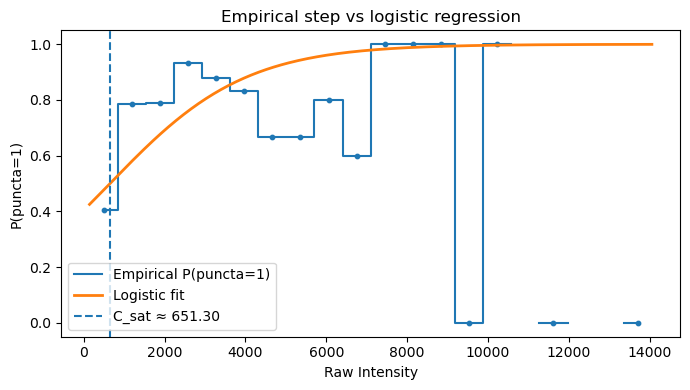

In [27]:
# Prepare data
X = intensity.reshape(-1, 1)
y = labels.astype(int)

# Basic sanity check
unique_labels = np.unique(y)
print("Unique labels in y:", unique_labels)
if len(unique_labels) < 2:
    raise ValueError("Need both puncta- and puncta+ cells to fit logistic regression.")

# Fit logistic regression with weak regularization
clf = LogisticRegression(
    solver="lbfgs",
    C=1e6,
    max_iter=1000,
    fit_intercept=True,
)
clf.fit(X, y)

b0 = clf.intercept_[0]
b1 = clf.coef_[0, 0]

print("Logistic intercept (b0):", b0)
print("Logistic slope (b1):    ", b1)

# C_sat = -b0 / b1 (intensity where P=0.5)
if np.isclose(b1, 0.0):
    csat = np.nan
    print("WARNING: Slope ~0, cannot define C_sat.")
else:
    csat = -b0 / b1
    print("Estimated C_sat (intensity units):", csat)

# Make smooth curve
x_grid = np.linspace(intensity.min(), intensity.max(), 300).reshape(-1,1)
p_grid = clf.predict_proba(x_grid)[:,1]

plt.figure(figsize=(7,4))

# empirical step
plt.step(bin_centers, bin_p, where="mid", label="Empirical P(puncta=1)")
plt.scatter(bin_centers, bin_p, s=10)

# logistic curve
plt.plot(x_grid.ravel(), p_grid, label="Logistic fit", linewidth=2)

# C_sat vertical line
if not np.isnan(csat):
    plt.axvline(csat, linestyle="--", label=f"C_sat ≈ {csat:.2f}")

plt.ylim(-0.05, 1.05)
plt.xlabel("Raw Intensity")
plt.ylabel("P(puncta=1)")
plt.title("Empirical step vs logistic regression")
plt.legend()
plt.tight_layout()
plt.show()


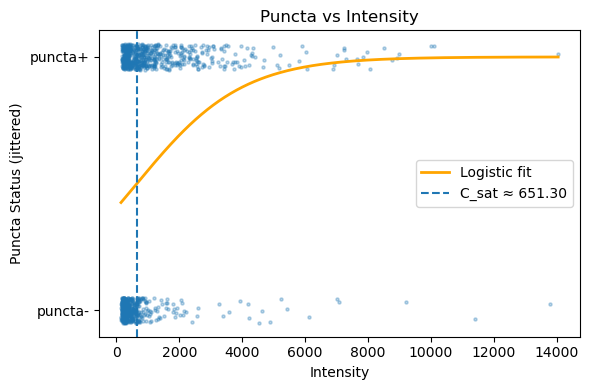

In [28]:
plt.figure(figsize=(6,4))

x = df_filt[INTENSITY_COL].to_numpy()
y = df_filt[PUNCTA_COL].to_numpy()

# jitter around 0 or 1 for visualization
y_jitter = y + (np.random.rand(len(y)) - 0.5) * 0.1

plt.plot(x_grid.ravel(), p_grid, label="Logistic fit", linewidth=2, color="orange")

# C_sat vertical line
if not np.isnan(csat):
    plt.axvline(csat, linestyle="--", label=f"C_sat ≈ {csat:.2f}")
    
plt.scatter(x, y_jitter, s=5, alpha=0.3)
plt.yticks([0, 1], ["puncta-", "puncta+"])
plt.xlabel('Intensity')
plt.ylabel("Puncta Status (jittered)")
plt.legend()
plt.title("Puncta vs Intensity")
plt.tight_layout()
plt.show()

Bootstrap C_sat median: 104.830
Bootstrap C_sat 95% CI: [-89.872, 200.213]
Effective bootstrap samples: 1000


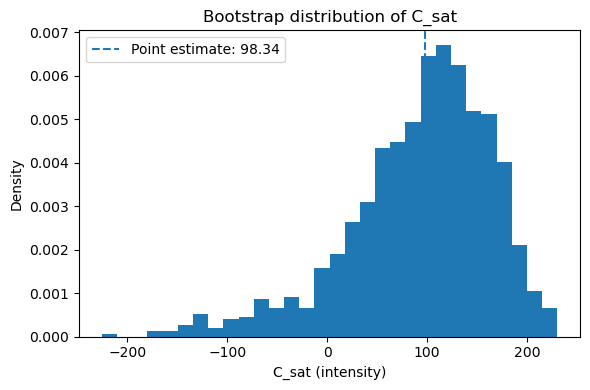

In [15]:
def bootstrap_csat(intensity, puncta, n_iters=1000, random_state=0):
    rng = np.random.default_rng(random_state)
    n = len(intensity)
    csat_samples = []

    for _ in range(n_iters):
        idx = rng.integers(0, n, size=n)
        x_bs = intensity[idx].reshape(-1,1)
        y_bs = puncta[idx].astype(int)

        if len(np.unique(y_bs)) < 2:
            continue

        clf_bs = LogisticRegression(
            solver="lbfgs",
            C=1e6,
            max_iter=1000,
            fit_intercept=True,
        )
        clf_bs.fit(x_bs, y_bs)
        b0_bs = clf_bs.intercept_[0]
        b1_bs = clf_bs.coef_[0,0]

        if not np.isclose(b1_bs, 0.0):
            csat_bs = -b0_bs / b1_bs
            csat_samples.append(csat_bs)

    csat_samples = np.array(csat_samples)
    if csat_samples.size == 0:
        return np.nan, (np.nan, np.nan), csat_samples

    median = np.median(csat_samples)
    lo = np.percentile(csat_samples, 2.5)
    hi = np.percentile(csat_samples, 97.5)
    return float(median), (float(lo), float(hi)), csat_samples

csat_median, (csat_lo, csat_hi), csat_samples = bootstrap_csat(
    intensity, y, n_iters=BOOTSTRAP_ITERS, random_state=RANDOM_STATE
)

print(f"Bootstrap C_sat median: {csat_median:.3f}")
print(f"Bootstrap C_sat 95% CI: [{csat_lo:.3f}, {csat_hi:.3f}]")
print("Effective bootstrap samples:", len(csat_samples))

# Optional: histogram of bootstrap C_sat
plt.figure(figsize=(6,4))
plt.hist(csat_samples, bins=30, density=True)
plt.axvline(csat, linestyle="--", label=f"Point estimate: {csat:.2f}")
plt.xlabel("C_sat (intensity)")
plt.ylabel("Density")
plt.title("Bootstrap distribution of C_sat")
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
cols_to_show = [
    "image_location",
    "cell_label",
    INTENSITY_COL,
    "puncta_area_in_cell",
    "puncta_density",
    "sat_frac_cell",
    "num_cyto_pixels",
    "cyto_file",
    "puncta_file",
    "intensity_file",
    "centroid_y",
    "centroid_x",
]

avail_cols = [c for c in cols_to_show if c in df_filt.columns]

puncta_neg = df_filt[df_filt[PUNCTA_COL] == 0].copy()
puncta_neg_sorted = puncta_neg.sort_values(INTENSITY_COL)

print("Total puncta- cells:", len(puncta_neg_sorted))
puncta_neg_sorted[avail_cols].head(20)


Total puncta- cells: 494


,image_location,cell_label,cyto_mean_raw,puncta_area_in_cell,puncta_density,sat_frac_cell,num_cyto_pixels,cyto_file,puncta_file,intensity_file,centroid_y,centroid_x
766,92_Z005,1,132.037338,0,0.0,0.0,33269,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,803.945084,162.553578
767,92_Z005,2,134.601471,0,0.0,0.0,48628,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,1059.630645,304.373365
15,101_Z005,7,135.989120,0,0.0,0.0,27034,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,1788.106126,1716.047570
14,101_Z005,6,136.147888,0,0.0,0.0,20982,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,1537.209799,1706.654132
522,34_Z005,6,138.376114,0,0.0,0.0,30780,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2110.129532,1419.109877
91,116_Z005,3,143.736862,0,0.0,0.0,17010,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,1951.005291,159.668372
671,63_Z005,5,143.833755,0,0.0,0.0,28266,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,1411.640204,2152.089259
689,70_Z005,1,149.241226,0,0.0,0.0,19310,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,892.122838,368.263231
139,127_Z005,2,150.149567,0,0.0,0.0,37674,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,386.110262,2113.941817
521,34_Z005,5,150.887970,0,0.0,0.0,49800,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2025.11.21_HeLa P9_p936 1ug p893 1ug_Nucleus_0...,2020.382430,1785.187831


In [24]:
LAB_COL = "has_puncta"

# Work on a copy sorted by intensity
df_sorted = df_filt.sort_values(INTENSITY_COL).reset_index(drop=True)

# If there are no puncta+ cells, there is no C_sat
if (df_sorted[LAB_COL] == 1).sum() == 0:
    csat_emp = None
    ok = False
    note = "No puncta-positive cells in data."
else:
    # 1) empirical candidate: smallest intensity with puncta+
    csat_emp = df_sorted.loc[df_sorted[LAB_COL] == 1, INTENSITY_COL].iloc[0]

    # 2) sanity check: all cells strictly below this intensity must be puncta-
    below_mask = df_sorted[INTENSITY_COL] < csat_emp
    any_pos_below = (df_sorted.loc[below_mask, LAB_COL] == 1).any()

    ok = not any_pos_below
    if ok:
        note = "OK: all cells below C_sat are puncta-."
    else:
        note = (
            "Sanity check FAILED: there exists at least one puncta+ cell "
            "with intensity < C_sat_emp."
        )

csat_emp, ok, note


(np.float64(131.7137451171875), True, 'OK: all cells below C_sat are puncta-.')

In [77]:
df_filt[['global_intensity_bg_sub', PUNCTA_COL]].describe()

,global_intensity_bg_sub,has_puncta
count,590.000000,590.000000
mean,3221.364230,0.933898
std,4985.477073,0.248671
min,29.207977,0.000000
25%,623.142517,1.000000
50%,1601.715637,1.000000
75%,3715.329956,1.000000
max,43539.562500,1.000000


In [73]:
df_filt.columns

Index(['image_location', 'cyto_file', 'puncta_file', 'intensity_file',
       'intensity_channel', 'cell_label', 'centroid_y', 'centroid_x',
       'num_cyto_pixels', 'num_puncta_pixels', 'has_puncta',
       'puncta_area_in_cell', 'puncta_density', 'background_method',
       'background_value_global', 'norm_percentile', 'norm_value_pXX',
       'local_bg_raw', 'local_bg_used', 'local_bg_source',
       'local_bg_pixels_used', 'cyto_mean_raw', 'cyto_mean_bgsub',
       'cyto_mean_norm', 'cyto_mean_bgsub_local', 'cyto_mean_norm_local',
       'cyto_mean_bgsub_hybrid', 'sat_frac_cell', 'conc_estimate_hybrid',
       'intensity_for_cs', 'global_intensity_bg_sub'],
      dtype='object')

In [44]:

# INT_COL = 'global_intensity_bg_sub'
# LAB_COL = "has_puncta"

# Work on a copy sorted by intensity
df_sorted = df_filt.sort_values(INTENSITY_COL).reset_index(drop=True)

# If there are no puncta+ cells, there is no C_sat
if (df_sorted[PUNCTA_COL] == 1).sum() == 0:
    csat_emp = None
    ok = False
    note = "No puncta-positive cells in data."
else:
    # 1) empirical candidate: smallest intensity with puncta+
    csat_emp = df_sorted.loc[df_sorted[PUNCTA_COL] == 1, INTENSITY_COL].iloc[0]

    # 2) sanity check: all cells strictly below this intensity must be puncta-
    below_mask = df_sorted[INTENSITY_COL] < csat_emp
    any_pos_below = (df_sorted.loc[below_mask, PUNCTA_COL] == 1).any()

    ok = not any_pos_below
    if ok:
        note = "OK: all cells below C_sat are puncta-."
    else:
        note = (
            "Sanity check FAILED: there exists at least one puncta+ cell "
            "with intensity < C_sat_emp."
        )

csat_emp, ok, note

(np.float64(61.41685485839844), True, 'OK: all cells below C_sat are puncta-.')

In [62]:
df.columns

Index(['image_location', 'cyto_file', 'puncta_file', 'intensity_file',
       'intensity_channel', 'cell_label', 'centroid_y', 'centroid_x',
       'num_cyto_pixels', 'num_puncta_pixels', 'has_puncta',
       'puncta_area_in_cell', 'puncta_density', 'background_method',
       'background_value_global', 'norm_percentile', 'norm_value_pXX',
       'local_bg_raw', 'local_bg_used', 'local_bg_source',
       'local_bg_pixels_used', 'cyto_mean_raw', 'cyto_mean_bgsub',
       'cyto_mean_norm', 'cyto_mean_bgsub_local', 'cyto_mean_norm_local',
       'cyto_mean_bgsub_hybrid', 'sat_frac_cell', 'conc_estimate_hybrid',
       'intensity_for_cs'],
      dtype='object')

In [63]:
df.cyto_mean_raw - df.background_value_global

0      1666.401733
1       395.926025
2       688.776062
3       808.677124
4       639.085815
          ...     
659     753.804443
660    2112.239746
661    2134.181396
662     770.249939
663     778.203186
Length: 664, dtype: float64

In [ ]:
(df.cyto_mean_raw - df.background_value_global)

count      664.000000
mean      3899.100463
std       6834.032646
min         29.207977
25%        616.697662
50%       1682.535706
75%       4105.599365
max      62751.289062
dtype: float64

In [ ]:
df.cyto_mean_raw - df

,image_location,cyto_file,puncta_file,intensity_file,intensity_channel,cell_label,centroid_y,centroid_x,num_cyto_pixels,num_puncta_pixels,...,local_bg_pixels_used,cyto_mean_raw,cyto_mean_bgsub,cyto_mean_norm,cyto_mean_bgsub_local,cyto_mean_norm_local,cyto_mean_bgsub_hybrid,sat_frac_cell,conc_estimate_hybrid,intensity_for_cs
0,0_Z005,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,1,1,315.746666,573.466140,62005,5852,...,8219,1902.401733,1666.401611,0.291713,1194.401611,0.209087,1194.401611,0.0,NaN,1194.401611
1,0_Z005,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,1,2,284.147508,1882.545799,88124,5980,...,12069,631.926025,395.926056,0.069309,239.926086,0.042000,239.926086,0.0,NaN,239.926086
2,0_Z005,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,1,3,413.729574,1031.873304,88061,445,...,12227,924.776062,688.776062,0.120574,274.776062,0.048101,274.776062,0.0,NaN,274.776062
3,0_Z005,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,1,4,614.703601,702.958299,76090,3943,...,9543,1044.677124,808.677124,0.141564,122.677132,0.021475,122.677132,0.0,NaN,122.677132
4,0_Z005,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,1,7,1884.044165,1168.353289,56877,5563,...,8005,875.085815,639.085815,0.111876,483.085815,0.084567,483.085815,0.0,NaN,483.085815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,99_Z005,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,1,1,861.175823,864.611908,58195,522,...,9696,979.804443,753.804504,0.227255,86.804436,0.026170,86.804436,0.0,NaN,86.804436
660,9_Z005,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,1,1,146.482743,1495.225819,81561,2842,...,4144,2355.239746,2112.239990,0.116486,1424.239746,0.078544,1424.239746,0.0,NaN,1424.239746
661,9_Z005,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,1,3,1092.928208,2055.040258,79661,5530,...,6146,2377.181396,2134.181152,0.117696,1317.181396,0.072640,2134.181152,0.0,NaN,2134.181152
662,9_Z005,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,2025.09.11_H2B RFP P13_ID513 NES HOTag3 1ug_XY...,1,4,1364.899083,1608.359375,65856,377,...,9998,1013.249939,770.249939,0.042478,177.249954,0.009775,177.249954,0.0,NaN,177.249954


Cells total: 664, after filtering: 590
Empirical C_sat (intensity_for_cs): -11.830
Sanity check: OK (all below are puncta-)

Selected 12 cells near C_sat (within ±500.0 intensity units).
Image locations near C_sat: ['89_Z005' '18_Z005' '181_Z005' '165_Z005' '198_Z005' '151_Z005'
 '233_Z005' '28_Z005' '136_Z005' '95_Z005' '21_Z005']


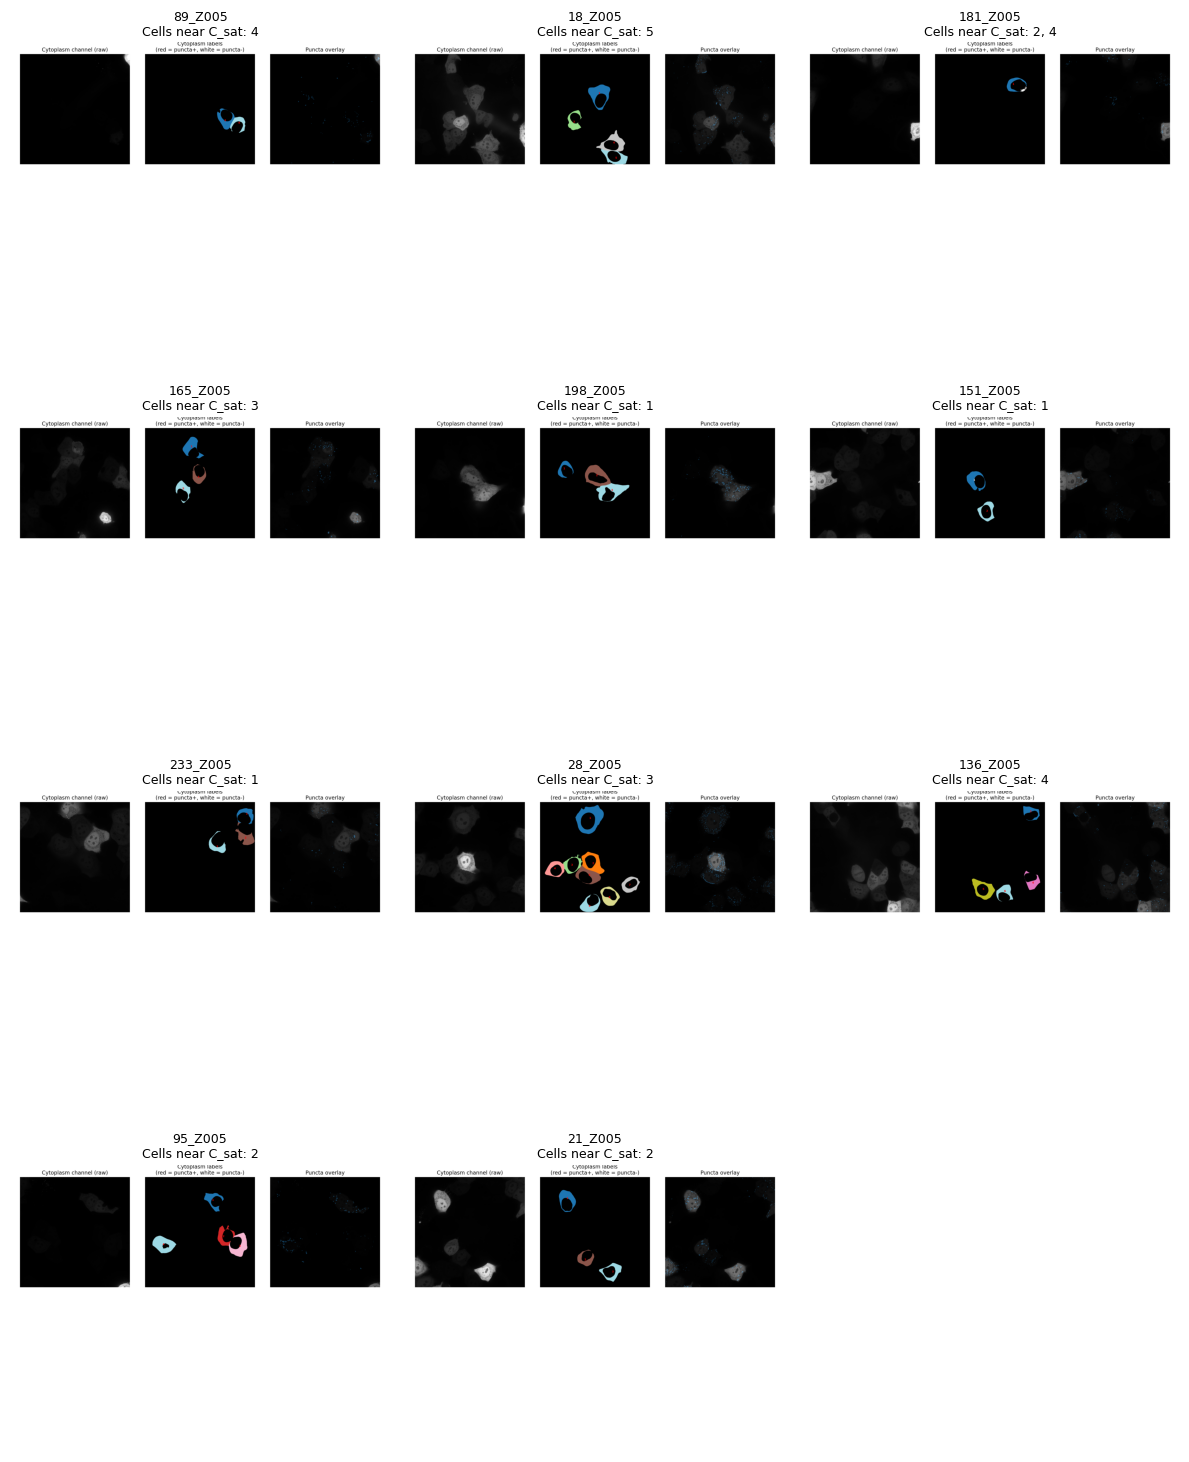

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# --- paths: EDIT THESE ---
CSV_PATH = Path("output/puncta_summary.csv")          # your per-cell CSV from summarize_puncta_by_cell.py
TRIPTYCH_DIR = Path("output/triptychs")               # --triptych-out-dir you used in the script

INT_COL = "intensity_for_cs"
PUNCTA_COL = "has_puncta"

# -------- 1) Load and (optionally) filter the dataframe --------
df = pd.read_csv(CSV_PATH)

# Optional: apply same filters you used for C_sat estimation
mask = np.ones(len(df), dtype=bool)

if "sat_frac_cell" in df.columns:
    mask &= df["sat_frac_cell"] <= 0.02      # tweak as needed

if "num_cyto_pixels" in df.columns:
    mask &= df["num_cyto_pixels"] >= 50      # tweak as needed

df_filt = df[mask].copy()
print(f"Cells total: {len(df)}, after filtering: {len(df_filt)}")

# -------- 2) Compute empirical C_sat from intensity_for_cs --------
# Sort by intensity
df_sorted = df_filt.sort_values(INT_COL).reset_index(drop=True)

# Check that we actually have puncta+ cells
if (df_sorted[PUNCTA_COL] == 1).sum() == 0:
    raise ValueError("No puncta-positive cells in filtered data — cannot define empirical C_sat.")

# Smallest intensity with puncta+
csat_emp = df_sorted.loc[df_sorted[PUNCTA_COL] == 1, INT_COL].iloc[0]

# Sanity check: all cells below C_sat must be puncta-
below_mask = df_sorted[INT_COL] < csat_emp
any_pos_below = (df_sorted.loc[below_mask, PUNCTA_COL] == 1).any()

print(f"Empirical C_sat (intensity_for_cs): {csat_emp:.3f}")
print("Sanity check:",
      "OK (all below are puncta-)" if not any_pos_below else "FAILED (puncta+ found below C_sat)")

# -------- 3) Find cells near C_sat --------
# Define a window around C_sat in intensity units
# Option A: absolute window
WINDOW = 500.0   # tweak based on your scale

# Option B (alternative): relative window as a fraction of range
# intensity_range = df_filt[INT_COL].max() - df_filt[INT_COL].min()
# WINDOW = 0.05 * intensity_range   # 5% of range

df_filt["delta_from_csat"] = np.abs(df_filt[INT_COL] - csat_emp)

# Keep cells within the window, then take the closest N
N_CELLS = 12  # how many "near C_sat" cells you want to inspect
df_near = df_filt[df_filt["delta_from_csat"] <= WINDOW].copy()
df_near = df_near.sort_values("delta_from_csat").head(N_CELLS)

print(f"\nSelected {len(df_near)} cells near C_sat (within ±{WINDOW} intensity units).")

# -------- 4) Group by image and show triptychs --------
# Since triptychs are per image, not per cell, we find which images these cells belong to
locations = df_near["image_location"].unique()
print("Image locations near C_sat:", locations)

# Helper to load a triptych image
def load_triptych(location: str) -> Image.Image:
    # This matches how summarize_puncta_by_cell.py names triptychs:
    # f"{location}_triptych.png"
    trip_name = f"{location}_triptych.png"
    trip_path = TRIPTYCH_DIR / trip_name
    if not trip_path.exists():
        raise FileNotFoundError(f"Triptych not found: {trip_path}")
    return Image.open(trip_path)

# Plot all triptychs for these locations in a grid
n_imgs = len(locations)
cols = 3
rows = int(np.ceil(n_imgs / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.atleast_1d(axes).ravel()

for ax, loc in zip(axes, locations):
    try:
        img = load_triptych(loc)
    except FileNotFoundError as e:
        ax.axis("off")
        ax.set_title(f"{loc}\n(NO triptych found)")
        continue

    ax.imshow(img)
    ax.axis("off")

    # Collect which cell labels in this image are "near C_sat"
    labels_here = df_near.loc[df_near["image_location"] == loc, "cell_label"].tolist()
    labels_str = ", ".join(str(int(x)) for x in labels_here)

    ax.set_title(f"{loc}\nCells near C_sat: {labels_str}", fontsize=9)

# Hide any unused subplots
for ax in axes[n_imgs:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [44]:
df.cyto_mean_raw

0      1902.401733
1       631.926025
2       924.776062
3      1044.677124
4       875.085815
          ...     
659     979.804443
660    2355.239746
661    2377.181396
662    1013.249939
663    1021.203186
Name: cyto_mean_raw, Length: 664, dtype: float64

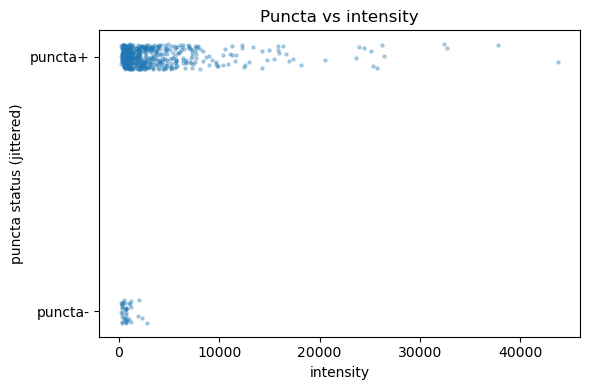

In [45]:
plt.figure(figsize=(6,4))

x = df_filt['cyto_mean_raw'].to_numpy()
y = df_filt[PUNCTA_COL].to_numpy()

# jitter around 0 or 1 for visualization
y_jitter = y + (np.random.rand(len(y)) - 0.5) * 0.1

plt.scatter(x, y_jitter, s=5, alpha=0.3)
plt.yticks([0, 1], ["puncta-", "puncta+"])
plt.xlabel('intensity')
plt.ylabel("puncta status (jittered)")
plt.title("Puncta vs intensity")
plt.tight_layout()
plt.show()
